In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

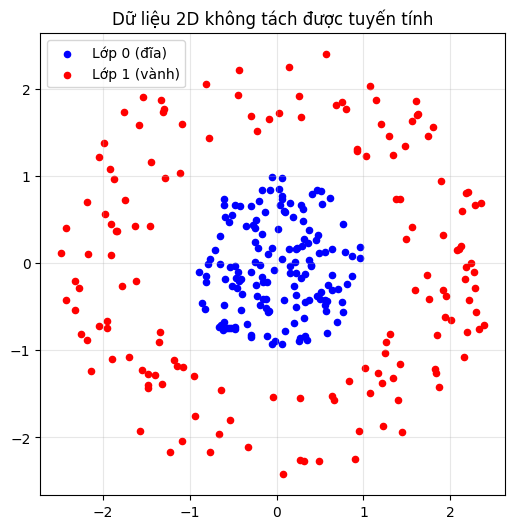

In [ ]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [ ]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


In [ ]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)


In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch  100/500  loss=0.3699  test_acc=83.33%
Epoch  200/500  loss=0.1062  test_acc=98.33%
Epoch  300/500  loss=0.0415  test_acc=100.00%
Epoch  400/500  loss=0.0222  test_acc=100.00%
Epoch  500/500  loss=0.0143  test_acc=100.00%


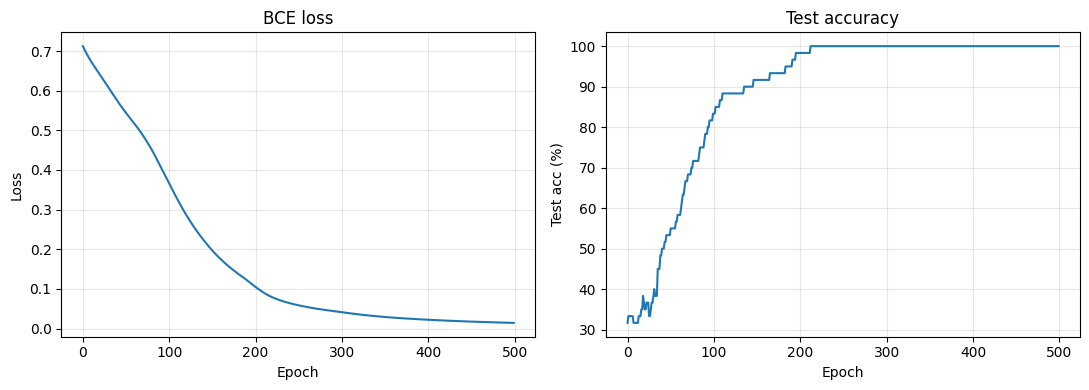

In [ ]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


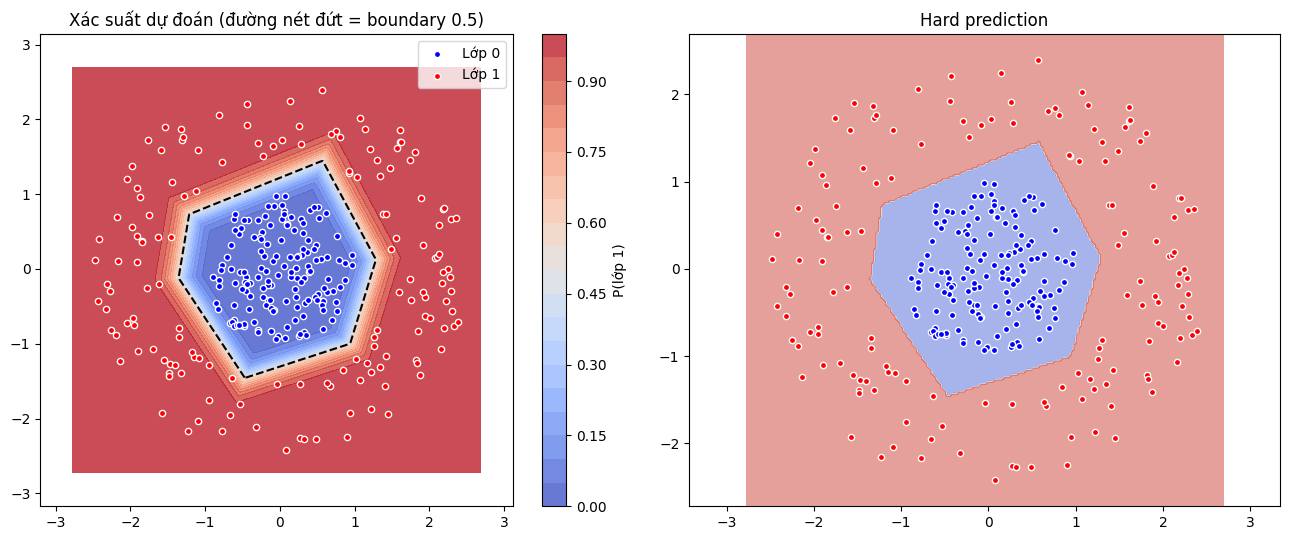

In [ ]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

In [1]:
#Bạn có thể cài đặt ANN (Artificial Neural Network) để dự báo thu nhập >50K hay <=50K
#Cài đặt thư viện
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#UpLoad file
print("Upload file adult.csv")

uploaded = files.upload()

# Đọc file
df = pd.read_csv("adult.csv")

Upload file adult.csv


Saving adult.csv to adult.csv


In [3]:
#Hiển thị dữ liệu
print("\n5 dòng đầu:")
print(df.head())

print("\nKích thước dữ liệu:")
print(df.shape)



5 dòng đầu:
   age         workclass  education      marital-status         occupation  \
0   39         State-gov  Bachelors       Never-married       Adm-clerical   
1   50  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2   38           Private    HS-grad            Divorced  Handlers-cleaners   
3   53           Private       11th  Married-civ-spouse  Handlers-cleaners   
4   28           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    race     sex  hours-per-week income  
0  White    Male              40  <=50K  
1  White    Male              13  <=50K  
2  White    Male              40  <=50K  
3  Black    Male              40  <=50K  
4  Black  Female              40   >50K  

Kích thước dữ liệu:
(5, 9)


In [4]:
#Xử lý dữ liệu
# Xóa dữ liệu thiếu
df.replace(" ?", np.nan, inplace=True)
df.dropna(inplace=True)

# Label Encoding
encoders = {}

for col in df.columns:
    if df[col].dtype == object:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

In [5]:
#Chia IP/OP
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
#Chuẩn hóa DL
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
#Xây dựng ANN
model = Sequential()

# Layer 1
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Layer 2
model.add(Dense(
    units=8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
#train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.6211 - val_accuracy: 1.0000 - val_loss: 0.6404
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.6667 - loss: 0.6119 - val_accuracy: 1.0000 - val_loss: 0.6391
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.6028 - val_accuracy: 1.0000 - val_loss: 0.6379
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.5939 - val_accuracy: 1.0000 - val_loss: 0.6366
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.5851 - val_accuracy: 1.0000 - val_loss: 0.6354
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.5765 - val_accuracy: 1.0000 - val_loss: 0.6344
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.5680 - val_accuracy: 1.0000 - val_loss: 0.6337
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.5597 - val_accuracy: 1.0000 - val_loss: 0.6330


In [ ]:
#đánh giá model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nĐộ chính xác:", accuracy)

In [11]:
#dự đoán model
y_pred = model.predict(X_test)

# Chuyển về 0 hoặc 1
y_pred = (y_pred > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


In [12]:
#Kết quả
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[0 1]
 [0 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [14]:
#test 5 dòng trước
print("\nKết quả dự đoán:")

for real, pred in zip(y_test, y_pred):

    print(
        "Thực tế:", real,
        "| Dự đoán:", pred[0]
    )


Kết quả dự đoán:
Thực tế: 0 | Dự đoán: 1


In [15]:
#dự đoán dữ liệu mới
print("\n==============================")
print("DỰ ĐOÁN NGƯỜI MỚI")
print("==============================")

sample = X_test[0].reshape(1, -1)

result = model.predict(sample)

if result > 0.5:
    print("Thu nhập >50K")
else:
    print("Thu nhập <=50K")


DỰ ĐOÁN NGƯỜI MỚI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Thu nhập >50K


In [16]:
#Bài 4: dự báo chất lượng xe ô tô
#Cài đặt thư viện
#UpLoad file
print("Upload file car.csv")

uploaded = files.upload()


Upload file car.csv


Saving car.csv to car.csv


In [17]:
#Đọc dữ liệu
df = pd.read_csv("car.csv")

print("\n5 dòng đầu:")
print(df.head())

print("\nKích thước dữ liệu:")
print(df.shape)


5 dòng đầu:
  buying  maint  doors persons lug_boot safety  class
0  vhigh  vhigh      2       2    small    low  unacc
1  vhigh  vhigh      2       2    small    med  unacc
2   high   high      4       4      med   high    acc
3    med    med      4    more      big   high   good
4    low    low  5more    more      big   high  vgood

Kích thước dữ liệu:
(5, 7)


In [18]:
#Xử lý dữ liệu
# Mã hóa dữ liệu dạng chữ
encoders = {}

for col in df.columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [19]:
#tách IP/OP
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [20]:
#train/ test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [21]:
#chuẩn hóa DL

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [22]:
#Xây dựng ANN
model = Sequential()

# Hidden layer 1
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Hidden layer 2
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
# Có 4 lớp => softmax
model.add(Dense(
    units=4,
    activation='softmax'
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
#train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 1.4712 - val_accuracy: 0.0000e+00 - val_loss: 1.6449
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.0000e+00 - loss: 1.4563 - val_accuracy: 0.0000e+00 - val_loss: 1.6493
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.0000e+00 - loss: 1.4418 - val_accuracy: 0.0000e+00 - val_loss: 1.6537
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.0000e+00 - loss: 1.4275 - val_accuracy: 0.0000e+00 - val_loss: 1.6581
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 0.0000e+00 - loss: 1.4134 - val_accuracy: 0.0000e+00 - val_loss: 1.6625
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.0000e+00 - loss: 1.3995 - val_accuracy: 0.0000e+00 - val_loss: 1.6669
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.0000e+00 - loss: 1.3857 - val_accuracy: 0.0000e+00 - val_loss: 1.6712
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.0

In [26]:
#đánh giá model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nĐộ chính xác:", accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 1.0000 - loss: 0.5496

Độ chính xác: 1.0


In [27]:
#dự đoán

y_pred = model.predict(X_test)

# Lấy class có xác suất lớn nhất
y_pred_classes = np.argmax(y_pred, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


In [28]:
#kết quả

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))


Confusion Matrix:
[[1]]

Classification Report:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [29]:
#dự đoán  5 dòng đầu tiên
print("\n5 dự đoán đầu tiên:")

n = min(5, len(y_test))

for i in range(n):

    print(
        "Thực tế:", y_test[i],
        "| Dự đoán:", y_pred_classes[i]
    )


5 dự đoán đầu tiên:
Thực tế: 2 | Dự đoán: 2


In [30]:
#dự đoán xe mới
print("\n==============================")
print("DỰ ĐOÁN XE MỚI")
print("==============================")

sample = X_test[0].reshape(1, -1)

result = model.predict(sample)

predicted_class = np.argmax(result)

print("Loại xe dự đoán:", predicted_class)

# Giải mã nhãn
label_name = encoders[df.columns[-1]].inverse_transform([predicted_class])

print("Chất lượng xe:", label_name[0])


DỰ ĐOÁN XE MỚI
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Loại xe dự đoán: 2
Chất lượng xe: unacc


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


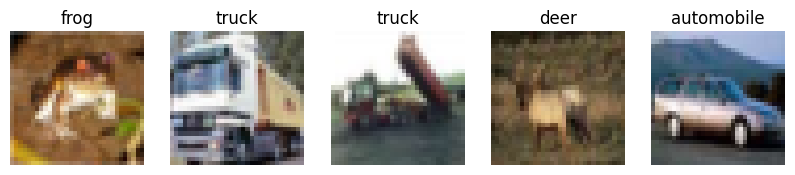

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.3155 - loss: 1.9047 - val_accuracy: 0.3596 - val_loss: 1.7894
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.3900 - loss: 1.7013 - val_accuracy: 0.3967 - val_loss: 1.6924
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4224 - loss: 1.6127 - val_accuracy: 0.4329 - val_loss: 1.6019
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4455 - loss: 1.5600 - val_accuracy: 0.4082 - val_loss: 1.6407
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4590 - loss: 1.5170 - val_accuracy: 0.4456 - val_loss: 1.5507
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4690 - loss: 1.4803 - val_accuracy: 0.4633 - val_loss: 1.5330
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4806 - loss: 1.4488 - val_accuracy: 0.4613 - val_loss: 1.5305
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4895 - loss: 1.4230 - 

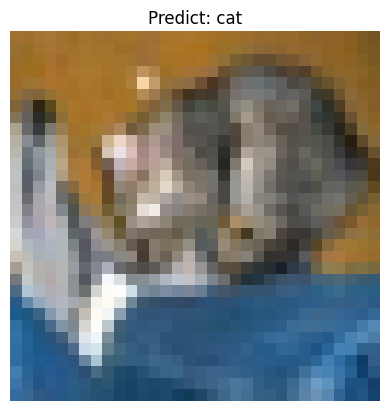

In [31]:
# ==========================================
# ANN NHẬN DẠNG ẢNH CIFAR10
# GOOGLE COLAB VERSION
# ==========================================

# CÀI THƯ VIỆN
!pip install tensorflow matplotlib

# ==========================================
# IMPORT THƯ VIỆN
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# ==========================================
# LOAD DATASET CIFAR10
# ==========================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# ==========================================
# DANH SÁCH NHÃN
# ==========================================

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# ==========================================
# KIỂM TRA DỮ LIỆU
# ==========================================

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# ==========================================
# CHUẨN HÓA DỮ LIỆU
# ==========================================

x_train = x_train / 255.0
x_test = x_test / 255.0

# ==========================================
# HIỂN THỊ 5 ẢNH ĐẦU TIÊN
# ==========================================

plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

plt.show()

# ==========================================
# XÂY DỰNG MÔ HÌNH ANN
# ==========================================

model = Sequential()

# Chuyển ảnh 32x32x3 thành vector
model.add(Flatten(input_shape=(32,32,3)))

# Hidden Layer 1
model.add(Dense(512, activation='relu'))

# Hidden Layer 2
model.add(Dense(256, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# HIỂN THỊ KIẾN TRÚC MODEL
# ==========================================

model.summary()

# ==========================================
# TRAIN MODEL
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ==========================================
# ĐÁNH GIÁ MODEL
# ==========================================

loss, accuracy = model.evaluate(x_test, y_test)

print("\nĐộ chính xác:", accuracy)

# ==========================================
# DỰ ĐOÁN
# ==========================================

predictions = model.predict(x_test)

# Lấy class có xác suất lớn nhất
predicted_labels = np.argmax(predictions, axis=1)

# ==========================================
# HIỂN THỊ 5 KẾT QUẢ DỰ ĐOÁN
# ==========================================

print("\n5 kết quả dự đoán đầu tiên:")

for i in range(5):

    print(
        "Thực tế:",
        class_names[y_test[i][0]],
        "| Dự đoán:",
        class_names[predicted_labels[i]]
    )

# ==========================================
# HIỂN THỊ 1 ẢNH TEST
# ==========================================

index = 0

plt.imshow(x_test[index])

plt.title(
    "Predict: " +
    class_names[predicted_labels[index]]
)

plt.axis('off')

plt.show()